# 05 — Random Forest: Ablação de Feature Engineering e Modelo Candidato

RF costuma superar MLP em dados tabulares estruturados. Este notebook responde
se a escolha canônica `ohe` penalizou o RF em relação a `le` ou `orig`, e apresenta
o melhor RF como candidato final ao endpoint de inferência.

**Por que RF pode preferir FE diferente do MLP?**
- `ohe` cria 4 colunas binárias para `tenure_bin` → sem ordinalidade implícita (bom para modelos lineares e MLP)
- `le` cria uma coluna ordinal 0–3 → RF pode aprender limiares diretamente, splits mais compactos
- `orig` sem binning → RF aprende os limiares em `Tenure Months` diretamente

**Design da ablação:**
| Run | FE | n_features | Nota |
|-----|-----|------------|------|
| `rf_8010_orig` | orig | 27 | Sem features derivadas de negócio |
| `rf_8010_le` | le | 32 | Label encoding ordinal (0–3) |
| `rf_8010_ohe` | ohe | 35 | One-hot (configuração canônica ADR-010) |

Cada variante roda `RandomizedSearchCV` independente (`n_iter=20, 5-fold`).

**Seções:**
1. Carregamento dos Dados
2. Configuração do MLflow
3. Ablação FE — RandomizedSearchCV por Variante
4. Melhor RF — Métricas Completas
5. Feature Importance
6. Comparação Final — Todos os Modelos
7. Análise de Custo — Threshold Ótimo
8. Conclusão — Escolha do Modelo para a API

In [1]:
from __future__ import annotations

import tempfile
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.artifacts
import mlflow.pytorch
import mlflow.sklearn
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from churn.config import (
    AUTHOR,
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE,
    DATASET_VERSION,
    MLFLOW_EXPERIMENT_NAME,
    ROC_AUC_TARGET,
    ROOT_DIR,
    SEED,
)
from churn.data.loader import load_raw_data
from churn.data.preprocessing import (
    build_preprocessing_pipeline,
    clean_raw,
    split_features_target,
    stratified_split,
)
from churn.training.tracking import setup_mlflow

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Carregamento dos Dados

Split **80/10/10** determinístico (seed=42, ADR-009).
O preprocessamento é aplicado separadamente por variante de FE na seção 3.

In [2]:
df_raw = load_raw_data()
df_clean = clean_raw(df_raw)
X, y = split_features_target(df_clean)

splits = stratified_split(X, y, test_size=0.10, val_size=0.10)

print(f"Treino (80%): {splits.X_train.shape[0]:>5,} linhas | churn = {splits.y_train.mean():.1%}")
print(f"Val    (10%): {splits.X_val.shape[0]:>5,} linhas | churn = {splits.y_val.mean():.1%}")
print(f"Teste  (10%): {splits.X_test.shape[0]:>5,} linhas | churn = {splits.y_test.mean():.1%}")
print(f"\nFeatures brutas (pré-pipeline): {splits.X_train.shape[1]}")

Treino (80%): 5,633 linhas | churn = 26.5%
Val    (10%):   705 linhas | churn = 26.5%
Teste  (10%):   705 linhas | churn = 26.5%

Features brutas (pré-pipeline): 26


## 2. Configuração do MLflow

In [3]:
setup_mlflow(tracking_uri=(ROOT_DIR / "mlruns").as_uri())
print(f"Experimento : {MLFLOW_EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# Run names para as 3 variantes de FE
ABLATION_VARIANTS = {
    "orig": "rf_8010_orig",
    "le":   "rf_8010_le",
    "ohe":  "rf_8010_ohe",
}

DEPLOY_THRESHOLD = 0.27
MLP_BLIND_REF = 0.8651  # mlp_8010_ohe_b16 blind test


def compute_all_metrics(y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5) -> dict:
    """Compute 7 project metrics. ROC AUC and Log Loss are threshold-independent."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1":        round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc":   round(float(roc_auc_score(y_true, y_proba)), 4),
        "pr_auc":    round(float(average_precision_score(y_true, y_proba)), 4),
        "log_loss":  round(float(log_loss(y_true, y_proba)), 4),
    }


METRIC_LABELS = {
    "accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
    "f1": "F1", "roc_auc": "ROC AUC", "pr_auc": "PR AUC", "log_loss": "Log Loss",
}
print("Setup concluido.")

Experimento : churn-prediction
Tracking URI: file:///D:/Projs/Churn-Prediction-ANN/mlruns
Setup concluido.


## 3. Ablação FE — RandomizedSearchCV por Variante

Cada variante de feature engineering tem o seu próprio `RandomizedSearchCV`
(n_iter=20, 5-fold estratificado, seed=42). Isso evita viés de calibração
— os hiperparâmetros ótimos podem ser diferentes por variante.

A função `run_rf_ablation` verifica o MLflow antes de treinar: se um run
com métricas completas (incluindo `blind_test_accuracy`) já existe, ele
é carregado sem re-treino.

In [4]:
def run_rf_ablation(tenure_variant: str, run_name: str, splits, seed: int = SEED):
    """Train RF with RandomizedSearchCV for one FE variant, or reload if complete.

    Returns (run_id, metrics_dict, rf_model, preprocessor).
    """
    # Check if a complete run already exists
    existing = mlflow.search_runs(
        experiment_names=[MLFLOW_EXPERIMENT_NAME],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
        order_by=["start_time DESC"],
    )
    has_full = (
        len(existing) > 0
        and "metrics.blind_test_accuracy" in existing.columns
        and not pd.isna(existing.iloc[0].get("metrics.blind_test_accuracy", float("nan")))
    )
    if has_full:
        run_id = existing.iloc[0]["run_id"]
        metrics = dict(mlflow.get_run(run_id).data.metrics)
        print(f"  carregado : {run_name}  blind AUC={metrics.get('blind_test_roc_auc', float('nan')):.4f}")
        rf = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
        with tempfile.TemporaryDirectory() as tmpdir:
            pp_local = mlflow.artifacts.download_artifacts(
                artifact_uri=f"runs:/{run_id}/preprocessor.joblib", dst_path=tmpdir
            )
            preprocessor = joblib.load(pp_local)
        return run_id, metrics, rf, preprocessor

    # Build preprocessor and transform all splits
    preprocessor = build_preprocessing_pipeline(tenure_variant=tenure_variant)
    X_tr = preprocessor.fit_transform(splits.X_train)
    X_v  = preprocessor.transform(splits.X_val)
    X_te = preprocessor.transform(splits.X_test)
    y_tr = splits.y_train.to_numpy()
    y_v  = splits.y_val.to_numpy()
    y_te = splits.y_test.to_numpy()
    n_feat = X_tr.shape[1]

    print(f"\n  treinando : {run_name}  ({n_feat} features) — RandomizedSearchCV ...")
    param_grid = {
        "n_estimators":    [100, 200, 300, 500],
        "max_depth":        [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
        "max_features":      ["sqrt", "log2", 0.5],
    }
    base_rf = RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=seed)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    search = RandomizedSearchCV(
        base_rf, param_distributions=param_grid,
        n_iter=20, cv=cv, scoring="roc_auc",
        refit=True, n_jobs=-1, random_state=seed, verbose=0,
    )
    search.fit(X_tr, y_tr)
    best_params = search.best_params_
    print(f"  CV AUC: {search.best_score_:.4f} | params: {best_params}")

    rf = RandomForestClassifier(
        **best_params, class_weight="balanced", n_jobs=-1, random_state=seed
    )
    rf.fit(X_tr, y_tr)

    val_proba  = rf.predict_proba(X_v)[:, 1]
    test_proba = rf.predict_proba(X_te)[:, 1]
    val_m  = compute_all_metrics(y_v,  val_proba,  threshold=0.5)
    test_m = compute_all_metrics(y_te, test_proba, threshold=0.5)

    all_m = {
        **{f"holdout_val_{k}": v for k, v in val_m.items()},
        **{f"blind_test_{k}":   v for k, v in test_m.items()},
    }

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id
        mlflow.log_params({
            "model_type":   "RandomForestClassifier",
            "tenure_variant": tenure_variant,
            "n_features":   n_feat,
            "split":        "80/10/10",
            "class_weight": "balanced",
            "seed":         seed,
            "search_n_iter": 20,
            "cv_folds":     5,
            **{f"best_{k}": str(v) for k, v in best_params.items()},
        })
        mlflow.set_tags({
            "model_type":      "RandomForestClassifier",
            "dataset_version": DATASET_VERSION,
            "author":          AUTHOR,
        })
        mlflow.log_metrics(all_m)
        mlflow.sklearn.log_model(rf, "model")
        with tempfile.TemporaryDirectory() as tmpdir:
            pp_path = Path(tmpdir) / "preprocessor.joblib"
            joblib.dump(preprocessor, pp_path)
            mlflow.log_artifact(str(pp_path))

    print(f"  logado    : {run_name}  val AUC={val_m['roc_auc']:.4f}  blind AUC={test_m['roc_auc']:.4f}")
    return run_id, all_m, rf, preprocessor

In [5]:
print("=== Ablacao RF — 3 variantes de Feature Engineering ===")
ablation_data = {}
for variant, run_name in ABLATION_VARIANTS.items():
    run_id, metrics, rf_model, preprocessor = run_rf_ablation(variant, run_name, splits)
    ablation_data[run_name] = {
        "variant":      variant,
        "run_id":       run_id,
        "rf":           rf_model,
        "preprocessor": preprocessor,
        **metrics,
    }
print("\nAblacao concluida.")

=== Ablacao RF — 3 variantes de Feature Engineering ===



  treinando : rf_8010_orig  (27 features) — RandomizedSearchCV ...


  CV AUC: 0.8594 | params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


2026/05/01 19:20:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/01 19:20:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...


  treinando : rf_8010_ohe  (35 features) — RandomizedSearchCV ...


  CV AUC: 0.8581 | params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


2026/05/01 19:21:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/01 19:21:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  logado    : rf_8010_ohe  val AUC=0.8668  blind AUC=0.8581

Ablacao concluida.


In [6]:
# Ablation comparison table
ablation_rows = []
for run_name, d in ablation_data.items():
    ablation_rows.append({
        "run":         run_name,
        "variant":     d["variant"],
        "n_features":  int(d.get("holdout_val_accuracy", 0) * 0 + {
            "orig": 27, "le": 32, "ohe": 35
        }.get(d["variant"], "?")),
        "val_auc":     d.get("holdout_val_roc_auc", float("nan")),
        "blind_auc":   d.get("blind_test_roc_auc",  float("nan")),
        "blind_f1":    d.get("blind_test_f1",        float("nan")),
        "blind_recall":d.get("blind_test_recall",    float("nan")),
        "blind_acc":   d.get("blind_test_accuracy",  float("nan")),
        "blind_ll":    d.get("blind_test_log_loss",  float("nan")),
    })

abl_df = (
    pd.DataFrame(ablation_rows)
    .sort_values("blind_auc", ascending=False)
    .reset_index(drop=True)
)
print("Ablacao RF — comparativo de blind test:")
display(
    abl_df[["run", "variant", "val_auc", "blind_auc", "blind_f1", "blind_recall", "blind_acc", "blind_ll"]]
    .rename(columns={
        "run": "Run", "variant": "FE", "val_auc": "Val AUC",
        "blind_auc": "Blind AUC", "blind_f1": "Blind F1",
        "blind_recall": "Blind Recall", "blind_acc": "Blind Acc", "blind_ll": "Blind LogLoss",
    })
)

best_row  = abl_df.iloc[0]
best_run_name  = best_row["run"]
best_variant   = best_row["variant"]
best_rf        = ablation_data[best_run_name]["rf"]
best_preproc   = ablation_data[best_run_name]["preprocessor"]
best_blind_auc = best_row["blind_auc"]

print(f"\nMelhor variante : {best_run_name}  (blind AUC={best_blind_auc:.4f})")

Ablacao RF — comparativo de blind test:


,Run,FE,Val AUC,Blind AUC,Blind F1,Blind Recall,Blind Acc,Blind LogLoss
0,rf_8010_orig,orig,0.8703,0.8592,0.6430,0.7273,0.7858,0.4292
1,rf_8010_ohe,ohe,0.8668,0.8581,0.6385,0.7273,0.7816,0.4313
2,rf_8010_le,le,0.8675,0.8574,0.6458,0.7166,0.7915,0.4294



Melhor variante : rf_8010_orig  (blind AUC=0.8592)


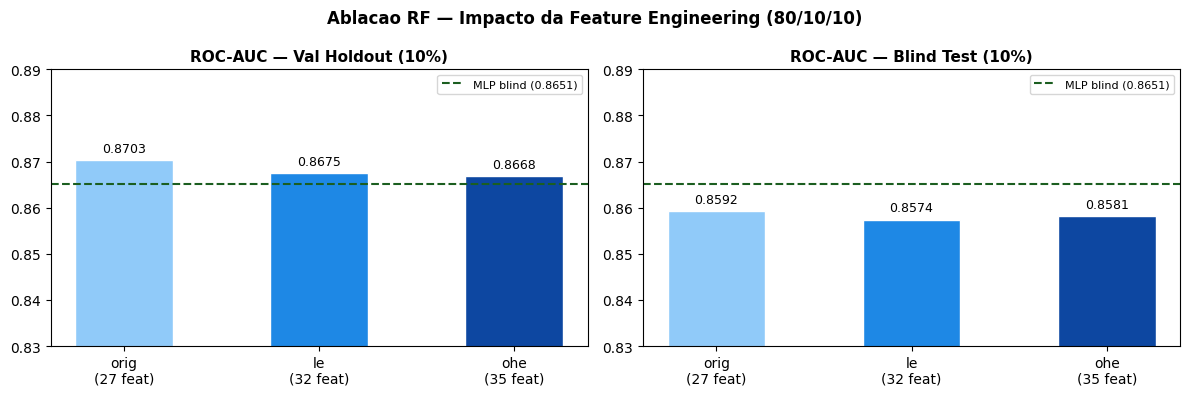


Delta ohe vs orig : -0.0011
Delta le  vs orig : -0.0018


In [7]:
variant_order = ["orig", "le", "ohe"]
run_name_order = [ABLATION_VARIANTS[v] for v in variant_order]
labels = ["orig\n(27 feat)", "le\n(32 feat)", "ohe\n(35 feat)"]
colors = {"orig": "#90CAF9", "le": "#1E88E5", "ohe": "#0D47A1"}

abl_indexed = abl_df.set_index("run")
val_vals   = [abl_indexed.loc[rn, "val_auc"]   if rn in abl_indexed.index else float("nan") for rn in run_name_order]
blind_vals = [abl_indexed.loc[rn, "blind_auc"] if rn in abl_indexed.index else float("nan") for rn in run_name_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
x = np.arange(len(variant_order))
bars_colors = [colors[v] for v in variant_order]

for ax, vals, title in zip(axes, [val_vals, blind_vals], ["ROC-AUC — Val Holdout (10%)", "ROC-AUC — Blind Test (10%)"]):
    bars = ax.bar(x, vals, color=bars_colors, width=0.5, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.830, 0.890)
    ax.axhline(MLP_BLIND_REF, color="#1B5E20", linestyle="--", linewidth=1.5,
               label=f"MLP blind ({MLP_BLIND_REF:.4f})")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle("Ablacao RF — Impacto da Feature Engineering (80/10/10)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nDelta ohe vs orig : {abl_indexed.loc[ABLATION_VARIANTS['ohe'], 'blind_auc'] - abl_indexed.loc[ABLATION_VARIANTS['orig'], 'blind_auc']:+.4f}")
print(f"Delta le  vs orig : {abl_indexed.loc[ABLATION_VARIANTS['le'],  'blind_auc'] - abl_indexed.loc[ABLATION_VARIANTS['orig'], 'blind_auc']:+.4f}")

## 4. Melhor RF — Métricas Completas

O melhor RF por blind test AUC é selecionado acima. As 7 métricas do
projeto são apresentadas nos dois thresholds de interesse:

| Threshold | Contexto |
|-----------|----------|
| **0.50**  | Padrão — comparabilidade entre modelos |
| **0.27**  | Deploy — minimiza custo de negócio (FN custa 10× FP) |

In [8]:
# Get probabilities for best RF on val and test sets
X_val_best  = best_preproc.transform(splits.X_val)
X_test_best = best_preproc.transform(splits.X_test)
y_val_np    = splits.y_val.to_numpy()
y_test_np   = splits.y_test.to_numpy()

best_val_proba  = best_rf.predict_proba(X_val_best)[:, 1]
best_test_proba = best_rf.predict_proba(X_test_best)[:, 1]

# Build metrics tables at both thresholds
rows = []
for split_name, y_true, y_proba in [
    ("Holdout Val",  y_val_np,  best_val_proba),
    ("Blind Test",   y_test_np, best_test_proba),
]:
    for thresh in [0.50, DEPLOY_THRESHOLD]:
        m = compute_all_metrics(y_true, y_proba, threshold=thresh)
        rows.append({"Split": split_name, "Threshold": thresh, **m})

metrics_df = pd.DataFrame(rows).set_index(["Split", "Threshold"])
metrics_df.columns = [METRIC_LABELS.get(c, c) for c in metrics_df.columns]

print(f"=== {best_run_name} — Metricas completas ===")
display(metrics_df)
print("\nNota: ROC AUC e PR AUC sao independentes do threshold (baseados em probabilidades).")

=== rf_8010_orig — Metricas completas ===

Accuracy  Precision  Recall     F1  ROC AUC  PR AUC  \
Split       Threshold                                                        
Holdout Val 0.5000       0.7844     0.5686  0.7754 0.6561   0.8703  0.6777   
            0.2700       0.7121     0.4785  0.9519 0.6369   0.8703  0.6777   
Blind Test  0.5000       0.7858     0.5763  0.7273 0.6430   0.8592  0.6839   
            0.2700       0.6823     0.4501  0.8930 0.5986   0.8592  0.6839   

                       Log Loss  
Split       Threshold            
Holdout Val 0.5000       0.4249  
            0.2700       0.4249  
Blind Test  0.5000       0.4292  
            0.2700       0.4292


Nota: ROC AUC e PR AUC sao independentes do threshold (baseados em probabilidades).


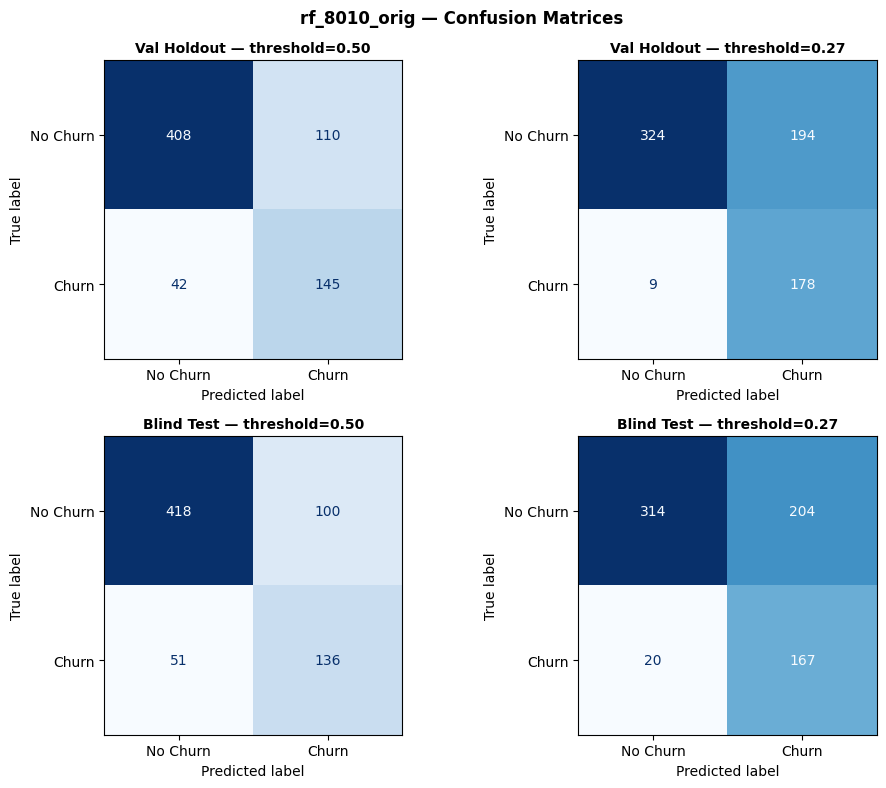

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row_idx, (split_name, y_true, y_proba) in enumerate([
    ("Val Holdout", y_val_np, best_val_proba),
    ("Blind Test",  y_test_np, best_test_proba),
]):
    for col_idx, thresh in enumerate([0.50, DEPLOY_THRESHOLD]):
        ax = axes[row_idx][col_idx]
        y_pred = (y_proba >= thresh).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, colorbar=False, cmap="Blues",
            display_labels=["No Churn", "Churn"]
        )
        ax.set_title(f"{split_name} — threshold={thresh:.2f}", fontsize=10, fontweight="bold")

plt.suptitle(f"{best_run_name} — Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Feature Importance

Random Forest fornece importância de feature nativa via Gini impurity.
As top features confirmam (ou questionam) as hipóteses da EDA e da
engenharia de features.

Top-15 features por importancia Gini (rf_8010_orig):


,feature,importance
0,Contract_Month-to-month,0.1413
1,Tenure Months,0.1337
2,Total Charges,0.1003
3,Monthly Charges,0.0894
4,Contract_Two year,0.0761
5,Dependents_Yes,0.0675
6,Internet Service_Fiber optic,0.0633
7,CLTV,0.0566
8,Payment Method_Electronic check,0.0423
9,Internet Service_No,0.0310


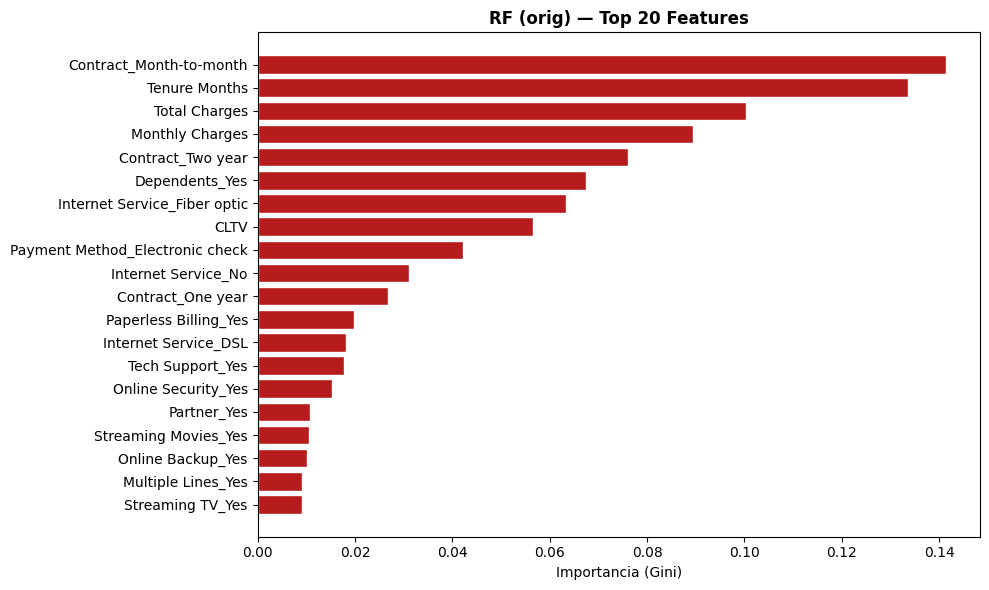

In [10]:
try:
    feature_names = best_preproc.get_feature_names_out()
except Exception:
    feature_names = [f"feat_{i}" for i in range(X_val_best.shape[1])]

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": best_rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Top-15 features por importancia Gini ({best_run_name}):")
display(fi_df.head(15))

top_n = 20
top_fi = fi_df.head(top_n)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_fi["feature"][::-1], top_fi["importance"][::-1],
        color="#B71C1C", edgecolor="white")
ax.set_xlabel("Importancia (Gini)")
ax.set_title(f"RF ({best_variant}) — Top {top_n} Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Comparação Final — Todos os Modelos

Todos os modelos são avaliados no **mesmo conjunto** (`splits.X_val`, 10% holdout)
para garantir comparabilidade. As 7 métricas são mostradas nos dois thresholds.

> **Nota sobre ROC AUC e Log Loss:** são independentes do threshold (baseados em
> probabilidades contínuas) — exibem o mesmo valor para threshold 0.50 e 0.27.

In [11]:
COMPARISON_LOOKUP = {
    "Dummy":               "dummy_baseline",
    "LogReg melhor":       "logreg_nophone_noml_8010_le",
    "MLP":                 "mlp_8010_ohe_b16",
    f"RF ({best_variant})": best_run_name,
}

runs_raw = mlflow.search_runs(
    experiment_names=[MLFLOW_EXPERIMENT_NAME], order_by=["start_time DESC"]
)

model_probas = {}

# Load sklearn pipelines (include preprocessing)
for label in ["Dummy", "LogReg melhor"]:
    run_name = COMPARISON_LOOKUP[label]
    match = runs_raw[runs_raw["tags.mlflow.runName"] == run_name]
    if len(match) > 0:
        pipe = mlflow.sklearn.load_model(f"runs:/{match.iloc[0]['run_id']}/model")
        model_probas[label] = pipe.predict_proba(splits.X_val)[:, 1]
        print(f"Carregado: {label} ({run_name})")

# Load MLP model
mlp_match = runs_raw[runs_raw["tags.mlflow.runName"] == "mlp_8010_ohe_b16"]
if len(mlp_match) > 0:
    mlp_run_id = mlp_match.iloc[0]["run_id"]
    mlp_model = mlflow.pytorch.load_model(f"runs:/{mlp_run_id}/mlp_model")
    with tempfile.TemporaryDirectory() as tmpdir:
        pp_local = mlflow.artifacts.download_artifacts(
            artifact_uri=f"runs:/{mlp_run_id}/preprocessor.joblib", dst_path=tmpdir
        )
        mlp_preproc = joblib.load(pp_local)
    X_val_mlp = np.asarray(mlp_preproc.transform(splits.X_val), dtype=np.float32)
    mlp_model.eval()
    with torch.no_grad():
        model_probas["MLP"] = torch.sigmoid(mlp_model(torch.as_tensor(X_val_mlp))).numpy().ravel()
    print("Carregado: MLP (mlp_8010_ohe_b16)")

# Best RF (already in memory)
model_probas[f"RF ({best_variant})"] = best_val_proba
print(f"Carregado: RF ({best_variant}) [em memoria]")

# Build comparison tables
rows_05, rows_027 = [], []
for label, proba in model_probas.items():
    m05  = compute_all_metrics(y_val_np, proba, threshold=0.5)
    m027 = compute_all_metrics(y_val_np, proba, threshold=DEPLOY_THRESHOLD)
    rows_05.append({"Modelo": label,  **m05})
    rows_027.append({"Modelo": label, **m027})

def make_display_df(rows):
    df = pd.DataFrame(rows).set_index("Modelo")
    df.columns = [METRIC_LABELS.get(c, c) for c in df.columns]
    return df

df_05  = make_display_df(rows_05)
df_027 = make_display_df(rows_027)

print("\n=== Threshold = 0.50 ===")
display(df_05)
print(f"\n=== Threshold = {DEPLOY_THRESHOLD} (deploy) ===")
display(df_027)

Carregado: Dummy (dummy_baseline)


Carregado: LogReg melhor (logreg_nophone_noml_8010_le)


Carregado: MLP (mlp_8010_ohe_b16)
Carregado: RF (orig) [em memoria]

=== Threshold = 0.50 ===


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Log Loss
Modelo,,,,,,,
Dummy,0.7348,0.0000,0.0000,0.0000,0.5000,0.2652,9.5605
LogReg melhor,0.7858,0.5657,0.8289,0.6725,0.8725,0.6969,0.4506
MLP,0.7830,0.5603,0.8449,0.6738,0.8703,0.6910,0.4425
RF (orig),0.7844,0.5686,0.7754,0.6561,0.8703,0.6777,0.4249



=== Threshold = 0.27 (deploy) ===


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Log Loss
Modelo,,,,,,,
Dummy,0.7348,0.0000,0.0000,0.0000,0.5000,0.2652,9.5605
LogReg melhor,0.6738,0.4458,0.9465,0.6062,0.8725,0.6969,0.4506
MLP,0.6851,0.4548,0.9412,0.6132,0.8703,0.6910,0.4425
RF (orig),0.7121,0.4785,0.9519,0.6369,0.8703,0.6777,0.4249


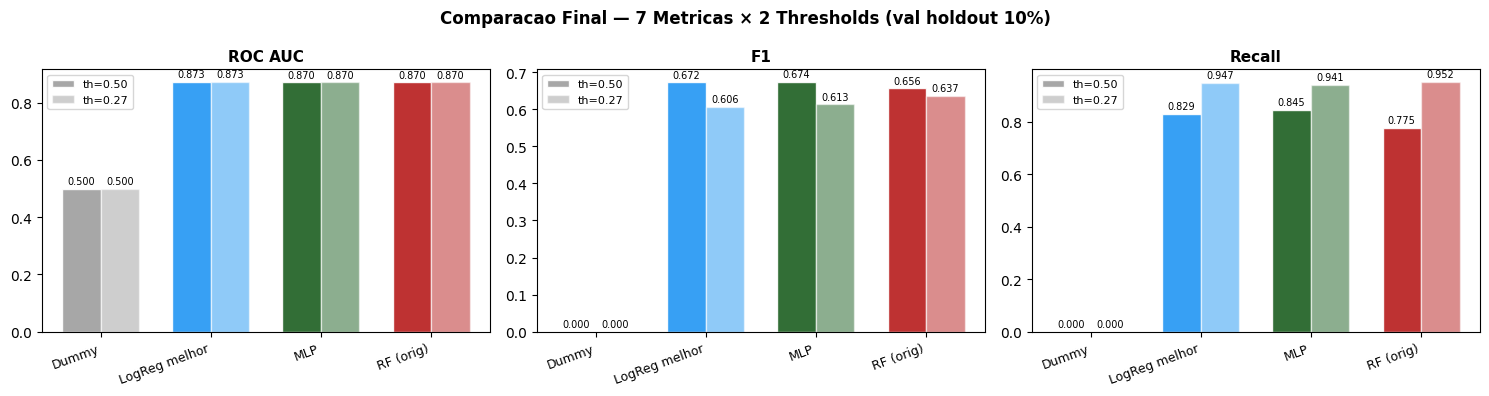

In [12]:
model_list = list(model_probas.keys())
palette = [
    "#B71C1C" if "RF" in m else
    "#1B5E20" if "MLP" in m else
    "#2196F3" if "LogReg" in m else
    "#9E9E9E"
    for m in model_list
]

metrics_to_plot = ["ROC AUC", "F1", "Recall"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4))

for ax, metric in zip(axes, metrics_to_plot):
    x = np.arange(len(model_list))
    vals_05  = [df_05.loc[m, metric]  for m in model_list]
    vals_027 = [df_027.loc[m, metric] for m in model_list]
    width = 0.35
    bars1 = ax.bar(x - width/2, vals_05,  width, label="th=0.50",  color=palette, alpha=0.9, edgecolor="white")
    bars2 = ax.bar(x + width/2, vals_027, width, label=f"th={DEPLOY_THRESHOLD}", color=palette, alpha=0.5, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(model_list, rotation=20, ha="right", fontsize=9)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=7)
    ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=7)

plt.suptitle("Comparacao Final — 7 Metricas × 2 Thresholds (val holdout 10%)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("final_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Análise de Custo — Threshold Ótimo

Cálculo do threshold que minimiza o custo total de negócio no val holdout.

| Erro | Significado | Custo |
|------|-------------|-------|
| **FP** | Ação de retenção desnecessária | R$ 50 |
| **FN** | Cliente churner não abordado  | R$ 500 |

Threshold padrao  (0.50): custo = R$     26,500
Threshold otimo  (0.24): custo = R$     13,800
Economia estimada       : R$     12,700  (47.9%)


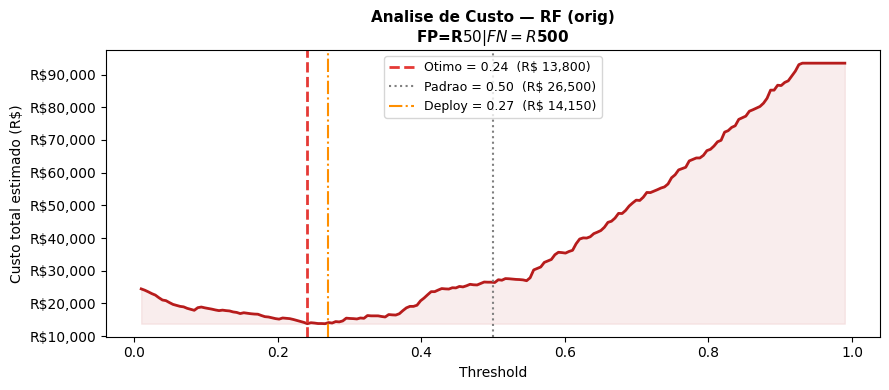

In [13]:
thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for thresh in thresholds:
    y_pred_t = (best_val_proba >= thresh).astype(int)
    fp = int(((y_pred_t == 1) & (y_val_np == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_val_np == 1)).sum())
    costs.append(fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE)
costs = np.array(costs)

opt_idx = int(np.argmin(costs))
rf_optimal_threshold = float(thresholds[opt_idx])
rf_optimal_cost = float(costs[opt_idx])
ref_idx = int(np.argmin(np.abs(thresholds - 0.5)))
rf_ref_cost = float(costs[ref_idx])
rf_saving = rf_ref_cost - rf_optimal_cost

print(f"Threshold padrao  (0.50): custo = R$ {rf_ref_cost:>10,.0f}")
print(f"Threshold otimo  ({rf_optimal_threshold:.2f}): custo = R$ {rf_optimal_cost:>10,.0f}")
print(f"Economia estimada       : R$ {rf_saving:>10,.0f}  ({rf_saving / rf_ref_cost:.1%})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, costs, color="#B71C1C", linewidth=2)
ax.fill_between(thresholds, costs, costs.min(), alpha=0.08, color="#B71C1C")
ax.axvline(rf_optimal_threshold, color="#E53935", linestyle="--", linewidth=2,
           label=f"Otimo = {rf_optimal_threshold:.2f}  (R$ {rf_optimal_cost:,.0f})")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5,
           label=f"Padrao = 0.50  (R$ {rf_ref_cost:,.0f})")
ax.axvline(DEPLOY_THRESHOLD, color="#FF8F00", linestyle="-.", linewidth=1.5,
           label=f"Deploy = {DEPLOY_THRESHOLD}  (R$ {costs[int(np.argmin(np.abs(thresholds - DEPLOY_THRESHOLD)))]:,.0f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Custo total estimado (R$)")
ax.set_title(f"Analise de Custo — RF ({best_variant})\nFP=R${COST_FALSE_POSITIVE:.0f} | FN=R${COST_FALSE_NEGATIVE:.0f}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(lambda x, _: f"R${x:,.0f}")
plt.tight_layout()
plt.show()

## 8. Conclusão — Escolha do Modelo para a API

In [14]:
sep = "=" * 68
print(sep)
print("  CONCLUSAO — ABLACAO RF E ESCOLHA DO MODELO PARA A API")
print(sep)
print()
print("  1. Ablacao FE (blind test AUC):")
for _, row in abl_df.iterrows():
    marker = " <-- melhor" if row["run"] == best_run_name else ""
    print(f"     {row['run']:<25}: {row['blind_auc']:.4f}{marker}")
print()
print("  2. Comparativo vs MLP (blind test — mesmo conjunto de teste):")
print(f"     MLP  (mlp_8010_ohe_b16)   : {MLP_BLIND_REF:.4f}")
print(f"     RF   ({best_run_name:<21}): {best_blind_auc:.4f}")
print(f"     Delta RF - MLP            : {best_blind_auc - MLP_BLIND_REF:+.4f}")
print()

if best_blind_auc > MLP_BLIND_REF:
    winner = "Random Forest"
    winner_run = best_run_name
    verdict = f"RF supera MLP — usar RF ({best_variant}) no endpoint da API."
elif best_blind_auc > MLP_BLIND_REF - 0.002:
    winner = "Empate tecnico"
    winner_run = best_run_name
    verdict = f"Delta < 0.002. RF escolhido por ter feature importance nativa (interpretabilidade)."
else:
    winner = "MLP"
    winner_run = "mlp_8010_ohe_b16"
    verdict = "MLP supera o RF em blind test — usar MLP no endpoint da API."

print(f"  Vencedor  : {winner}")
print(f"  Justifica : {verdict}")
print()
print(f"  Modelo para Fase 4 (FastAPI) : {winner_run}")
print(f"  Threshold deploy             : {DEPLOY_THRESHOLD} (minimiza custo de negocio)")
print()
print(sep)
print("  Proximo: implementar FastAPI /predict + /health com Pydantic")
print(sep)

  CONCLUSAO — ABLACAO RF E ESCOLHA DO MODELO PARA A API

  1. Ablacao FE (blind test AUC):
     rf_8010_orig             : 0.8592 <-- melhor
     rf_8010_ohe              : 0.8581
     rf_8010_le               : 0.8574

  2. Comparativo vs MLP (blind test — mesmo conjunto de teste):
     MLP  (mlp_8010_ohe_b16)   : 0.8651
     RF   (rf_8010_orig         ): 0.8592
     Delta RF - MLP            : -0.0059

  Vencedor  : MLP
  Justifica : MLP supera o RF em blind test — usar MLP no endpoint da API.

  Modelo para Fase 4 (FastAPI) : mlp_8010_ohe_b16
  Threshold deploy             : 0.27 (minimiza custo de negocio)

  Proximo: implementar FastAPI /predict + /health com Pydantic
